In [1]:

import os, io, time, json, hashlib, pathlib, sys
import requests
import pandas as pd
import numpy as np
import importlib
from dotenv import load_dotenv
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from urllib.parse import urlparse
from datetime import datetime, timedelta
import geoquant.configs.config as config
import geoquant.data_io as f1
import geoquant.series_utils as f2
import geoquant.risk_matrix as risk_matrix
import geoquant.books as books

# print(holdings.IBKR_live)

importlib.reload(books)
importlib.reload(f2)
importlib.reload(config)

print('ok')


STOOQ_API: rjpadqeTh6Uc8xu7F0D52AKXVsNEL9rC
STOOQ_API: rjpadqeTh6Uc8xu7F0D52AKXVsNEL9rC
STOOQ_API: rjpadqeTh6Uc8xu7F0D52AKXVsNEL9rC
ok


In [2]:
# Test single ticker download from stooq (FX: GBPCHF)
from geoquant.data_io import fetch_csv_robust

test_ticker = 'JPYCHF.FOREX'
test_params = config.data_params.copy()
test_params['max_age'] = 0  # force download

df_test = fetch_csv_robust(test_ticker, data_params=test_params)
print('Downloaded shape:', df_test.shape)
print(df_test.head())
print(df_test.tail())

+++fetch_csv_robust : JPYCHF.FOREX, config/data_params: {'start': Timestamp('2018-01-01 00:00:00'), 'datasource': 'stooq', 'max_age': 0, 'end': Timestamp('2026-05-08 00:00:00')}
JPYCHF - incremental update 2026-05-08 -> 2026-05-08

--- RAW CSV for JPYCHF from https://stooq.com/q/d/l/?s=JPYCHF&d1=20260508&d2=20260508&i=d&apikey=rjpadqeTh6Uc8xu7F0D52AKXVsNEL9rC ---
No data
--- END RAW CSV ---

JPYCHF - incremental fetch returned no rows; serving cache
Downloaded shape: (2159, 4)
                Open      High       Low     Close
Date                                              
2018-01-02  0.008650  0.008673  0.008633  0.008662
2018-01-03  0.008659  0.008717  0.008651  0.008682
2018-01-04  0.008682  0.008685  0.008633  0.008641
2018-01-05  0.008640  0.008644  0.008609  0.008620
2018-01-08  0.008620  0.008662  0.008614  0.008637
                Open      High       Low     Close
Date                                              
2026-05-01  0.004989  0.005016  0.004968  0.004977
2026-05-

holdings: [{'name': 'XMWX', 'ticker': 'XMWX.LSE', 'ccy': 'GBP', 'GBP_exposure': 0.1, 'gbx': False, 'include_fx_vol': True, 'position': 497}, {'name': 'EMIM', 'ticker': 'EMIM.LSE', 'ccy': 'GBP', 'USD_exposure': 0, 'gbx': True, 'position': 321}, {'name': 'GWX', 'ticker': 'GWX.US', 'ccy': 'USD', 'USD_exposure': 0, 'gbx': False, 'position': 203}, {'name': 'SGLN', 'ticker': 'SGLN.LSE', 'ccy': 'GBP', 'USD_exposure': 1.0, 'gbx': True, 'include_fx_vol': True, 'position': 68}, {'name': 'BATG', 'ticker': 'BATG.LSE', 'ccy': 'GBP', 'USD_exposure': 1.0, 'gbx': True, 'include_fx_vol': True, 'position': 173}, {'name': 'YCA', 'ticker': 'YCA.LSE', 'ccy': 'GBP', 'USD_exposure': 1.0, 'gbx': True, 'include_fx_vol': True, 'position': 689}, {'name': 'CASH_CHF', 'type': 'cash', 'ccy': 'CHF', 'amount': 12000, 'include_fx_vol': True}, {'name': 'CASH_JPY', 'ticker': 'JPYCHF.FOREX', 'type': 'cash', 'ccy': 'JPY', 'amount': 0, 'include_fx_vol': True}]
data_params: {'start': Timestamp('2018-01-01 00:00:00'), 'datas

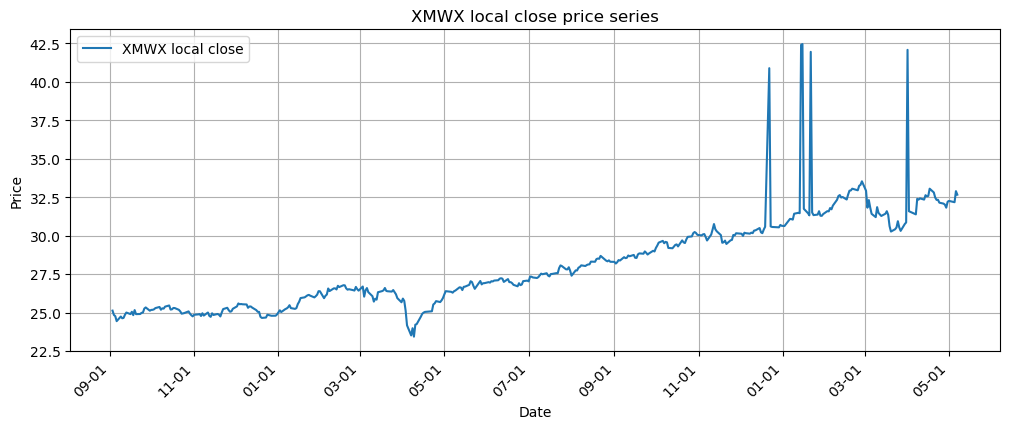

+++fetch_csv_robust : EMIM.LSE, config/data_params: {'start': Timestamp('2018-01-01 00:00:00'), 'datasource': 'stooq', 'max_age': 24, 'end': Timestamp('2026-05-08 00:00:00')}
EMIM.UK - using cached data
               Open    High     Low   Close   Volume
Date                                                
2026-04-09  3658.00  3663.0  3630.0  3658.0   141474
2026-04-10  3682.00  3700.0  3677.0  3686.0   127876
2026-04-13  3665.00  3681.0  3653.0  3677.0    90985
2026-04-14  3718.00  3742.0  3711.0  3742.0   150540
2026-04-15  3743.00  3757.0  3732.0  3757.0   815487
2026-04-16  3790.00  3793.0  3755.0  3784.0   145411
2026-04-17  3774.00  3873.0  3770.0  3864.0   184176
2026-04-20  3813.00  3825.0  3790.0  3818.0   946913
2026-04-21  3844.00  3851.0  3800.0  3803.0   420891
2026-04-22  3822.00  3841.0  3810.0  3841.0   107188
2026-04-23  3810.00  3822.0  3783.0  3822.0   226688
2026-04-24  3825.00  3855.0  3810.0  3850.0   260073
2026-04-27  3855.00  3862.0  3839.0  3840.0   223503
20

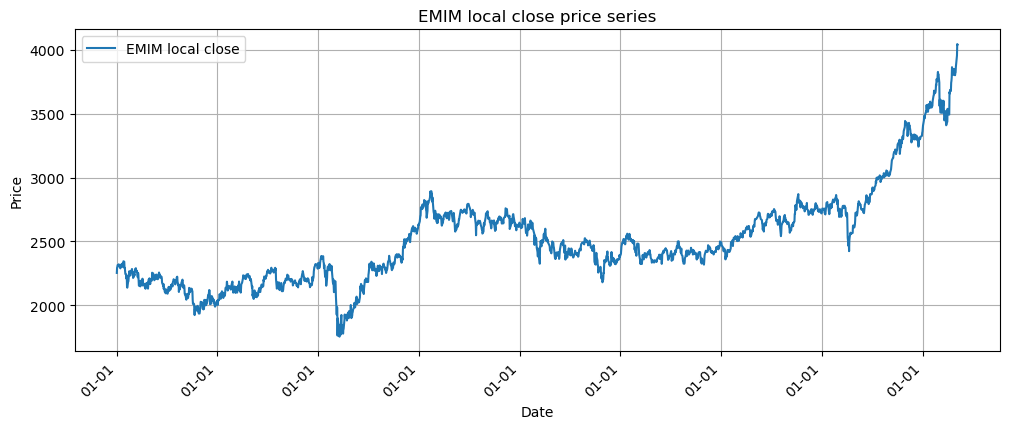

+++fetch_csv_robust : GWX.US, config/data_params: {'start': Timestamp('2018-01-01 00:00:00'), 'datasource': 'stooq', 'max_age': 24, 'end': Timestamp('2026-05-08 00:00:00')}
GWX.US - using cached data
                 Open     High      Low    Close    Volume
Date                                                      
2026-04-10  44.400000  44.5600  44.1600  44.2900   65076.0
2026-04-13  43.890000  44.7462  43.8102  44.7400   47788.0
2026-04-14  44.850000  45.3400  44.8500  45.3200   47335.0
2026-04-15  45.240000  45.3050  45.0600  45.2700   33072.0
2026-04-16  45.517568  45.6099  45.2801  45.4100   37756.0
2026-04-17  46.100000  46.5200  46.0001  46.0400   58184.0
2026-04-20  45.610000  45.8700  45.5900  45.8600   33190.0
2026-04-21  45.470000  45.6816  44.7350  44.9100   32947.0
2026-04-22  45.230000  45.4899  45.2000  45.3200   25149.0
2026-04-23  44.790000  45.3700  44.5600  44.9600   40588.0
2026-04-24  45.130000  45.3300  44.9900  45.1900   68544.0
2026-04-27  45.380000  45.5700  4

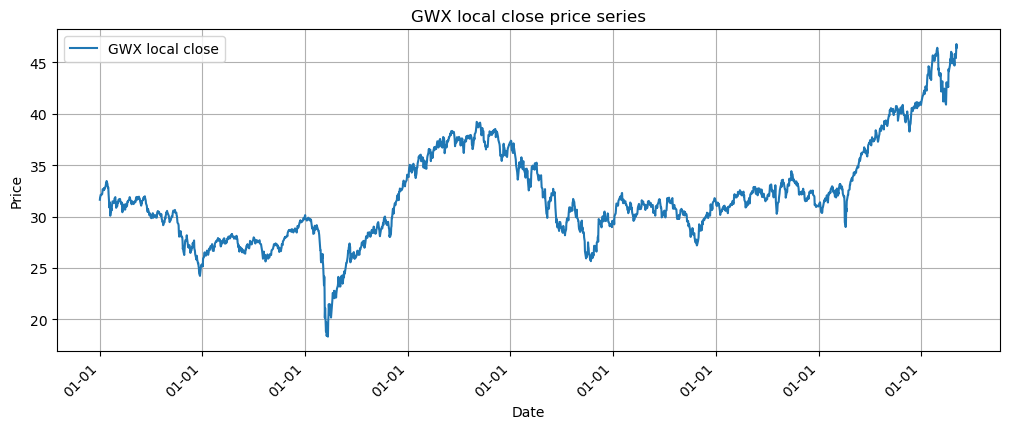

+++fetch_csv_robust : SGLN.LSE, config/data_params: {'start': Timestamp('2018-01-01 00:00:00'), 'datasource': 'stooq', 'max_age': 24, 'end': Timestamp('2026-05-08 00:00:00')}
SGLN.UK - using cached data
               Open     High      Low    Close  Volume
Date                                                  
2026-04-09  6828.00  6924.00  6822.00  6924.00  426597
2026-04-10  6866.00  6902.00  6846.00  6880.00  254455
2026-04-13  6840.00  6852.00  6780.00  6796.00  401424
2026-04-14  6861.00  6881.00  6806.00  6875.00  419698
2026-04-15  6886.00  6912.80  6854.00  6860.93  308643
2026-04-16  6898.00  6909.00  6850.00  6886.00  291499
2026-04-17  6876.00  6982.00  6860.00  6972.00  404075
2026-04-20  6892.89  6925.30  6869.14  6884.45  362482
2026-04-21  6857.00  6886.47  6777.35  6825.21  402965
2026-04-22  6842.00  6849.91  6794.00  6798.00  227974
2026-04-23  6779.00  6823.00  6735.00  6801.00  263662
2026-04-24  6736.00  6808.00  6725.00  6785.00  238557
2026-04-27  6757.00  6760.0

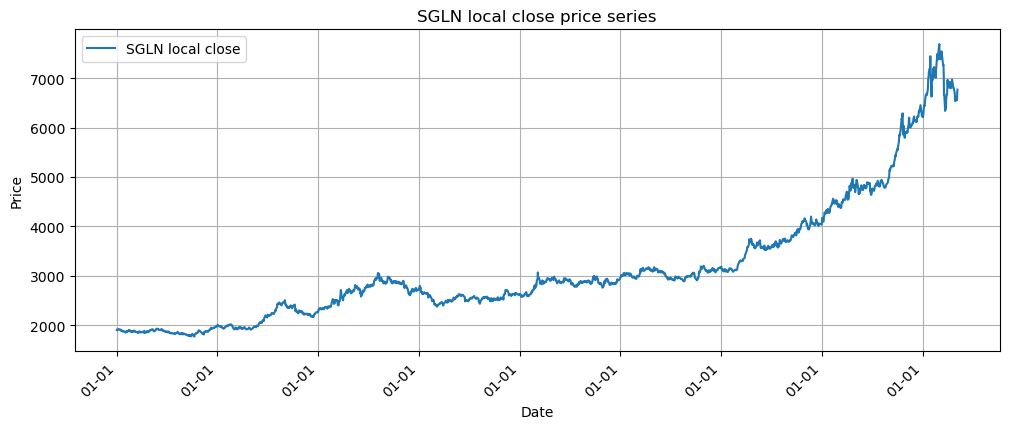

+++fetch_csv_robust : BATG.LSE, config/data_params: {'start': Timestamp('2018-01-01 00:00:00'), 'datasource': 'stooq', 'max_age': 24, 'end': Timestamp('2026-05-08 00:00:00')}
BATG.UK - using cached data
gap days: 23
required start: 2018-01-01 00:00:00 
data start: 2018-01-24
              Open    High      Low    Close  Volume
Date                                                
2026-04-09  2550.5  2559.0  2525.50  2542.00   11623
2026-04-10  2567.0  2605.5  2564.00  2602.00   10544
2026-04-13  2566.0  2614.0  2563.00  2614.00   34547
2026-04-14  2620.0  2653.5  2618.00  2653.50   31422
2026-04-15  2617.0  2651.5  2611.00  2631.50   17620
2026-04-16  2701.5  2721.5  2685.50  2713.00   34528
2026-04-17  2756.0  2794.0  2748.00  2780.00   33593
2026-04-20  2749.0  2788.0  2675.89  2775.10   10342
2026-04-21  2807.2  2823.0  2775.00  2794.27   40931
2026-04-22  2816.5  2839.5  2803.50  2839.50   33440
2026-04-23  2798.5  2820.0  2788.00  2804.00   18008
2026-04-24  2846.0  2852.5  2810.50

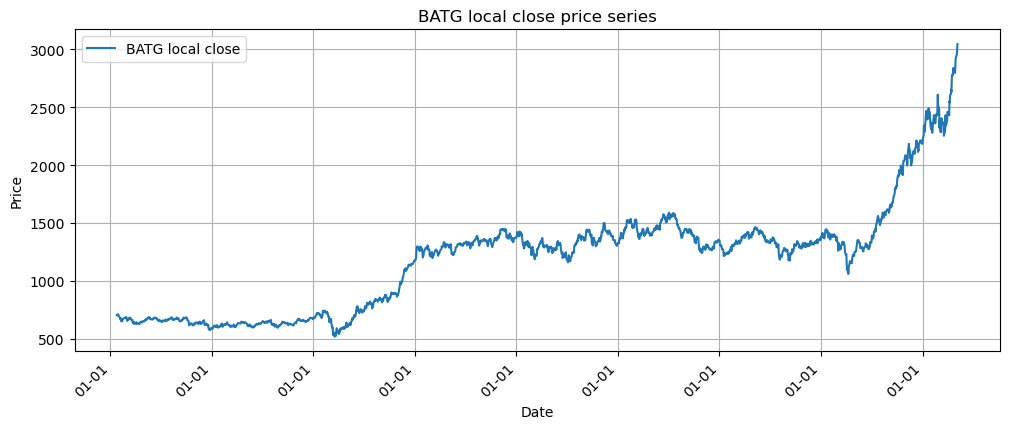

+++fetch_csv_robust : YCA.LSE, config/data_params: {'start': Timestamp('2018-01-01 00:00:00'), 'datasource': 'stooq', 'max_age': 24, 'end': Timestamp('2026-05-08 00:00:00')}
YCA.UK - using cached data
gap days: 185
required start: 2018-01-01 00:00:00 
data start: 2018-07-05
             Open    High      Low  Close   Volume
Date                                              
2026-04-09  614.5  617.00  593.000  600.0   827457
2026-04-10  590.5  600.00  588.000  596.5  1308241
2026-04-13  594.5  598.25  585.500  593.0  1021329
2026-04-14  605.0  610.00  600.500  604.0   704813
2026-04-15  604.5  613.00  602.000  611.0   851298
2026-04-16  610.5  623.00  608.500  619.5  1183412
2026-04-17  623.0  623.50  611.000  617.5  1336464
2026-04-20  620.0  620.00  604.000  611.5   868567
2026-04-21  613.5  625.50  599.893  601.0  1726357
2026-04-22  601.0  618.50  598.000  612.0  1972642
2026-04-23  616.5  623.50  606.500  612.5   969632
2026-04-24  608.5  612.50  597.000  600.5   913090
2026-04-27 

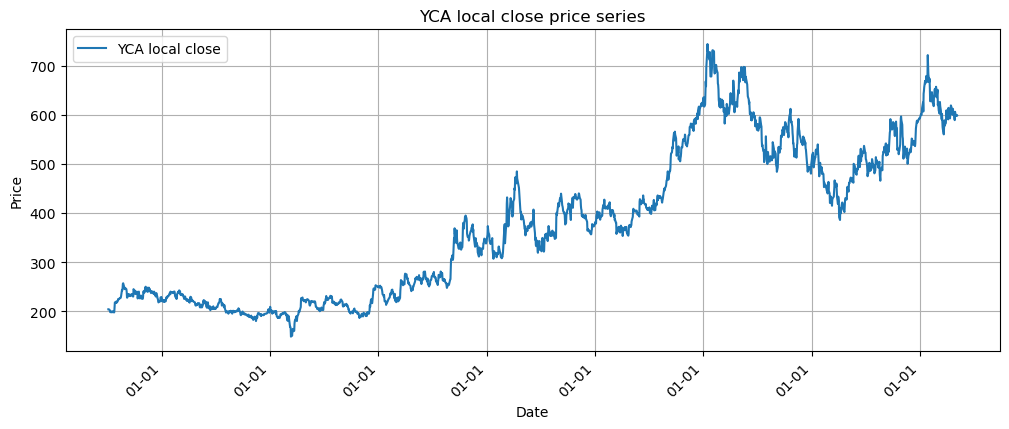

chf equiv latest 1.0
chf equiv latest 0.00497543
After alignment only 414 rows remain (expected 3049 days 00:00:00). Data source may not have full history.
asset close chf EMIM 40.41
LOOKBACK DAYS/REGIME: 2018-01-01 00:00:00 to 2026-05-08 00:00:00  (3049 days)
Total portfolio value (CHF): 65066.51
XMWX: value CHF17181.46,  last 32.90 *fx* 497
EMIM: value CHF13728.24,  last 40.45 *fx* 321
GWX: value CHF7341.31,  last 46.79 *fx* 203
SGLN: value CHF4870.69,  last 67.09 *fx* 68
BATG: value CHF5576.95,  last 30.22 *fx* 173
YCA: value CHF4367.84,  last 6.00 *fx* 689
CASH_CHF: value CHF12000.00,  last 1.00 *fx* 0.0
CASH_JPY: value CHF0.00,  last 0.00 *fx* 0.0
++++++ portfolio_risk()
------------
Portfolio σ (an_adjnualized, CHF): 21.93%
 CORE EQUITY BAND = 15 - 30%, DIVERSIFIERS = 5 - 12%, TACTICALS <= 10%,
equity core max 30%, diversifiers max 12%, tacticals max 10%, total max 15%
          Weight  Vol_1Y_CHF    MRC  PRC_%
XMWX       0.264       0.668  0.613   73.8
EMIM       0.211       0.1

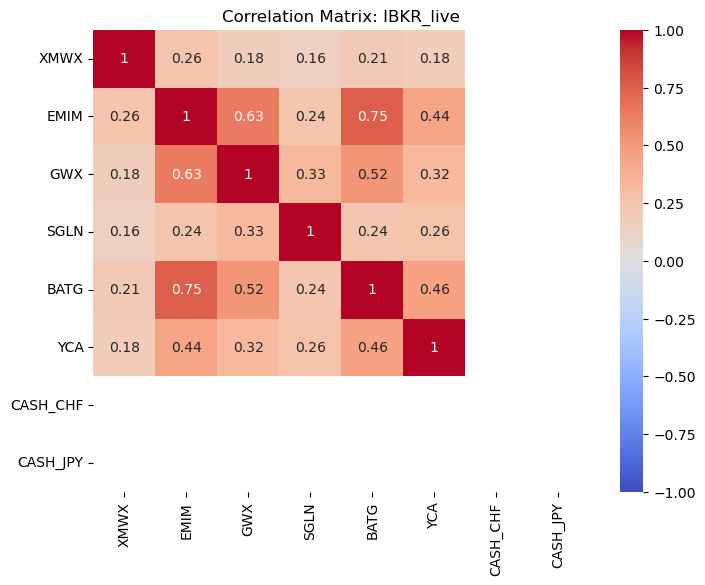

In [3]:

PORTFOLIO = 'IBKR_live' 
            # 'IBKR_live_adj'  
            # 'IBKR_sim' 
            # 'exp' 
holdings=getattr(books, PORTFOLIO)  # verify it exists

print('holdings:', holdings)

data_params = config.data_params
print('data_params:', data_params)
DEBUG = False
window_start = '2026-4-10'
window_end = None
print('------\nBOOK:', PORTFOLIO, '\n-------')
max_age = data_params.get('max_age', 0)
print('window_start:', window_start)
print('max_age (hrs):', max_age, '\n-------')

rets_df, prices_df, w = risk_matrix.build_returns_weights(holdings, data_params=config.data_params, no_fx=False, usd_shift=False, window_start=window_start, window_end=window_end)

risk = risk_matrix.portfolio_risk(rets_df, w)

# print( rets_df.tail(3) )
print("------------\nPortfolio σ (an_adjnualized, CHF): {:.2%}".format(risk["port_vol"]))
print(" CORE EQUITY BAND = 15 - 30%, DIVERSIFIERS = 5 - 12%, TACTICALS <= 10%,")
print('equity core max 30%, diversifiers max 12%, tacticals max 10%, total max 15%')
print(risk["summary"].round({"Weight":3,"Vol_1Y_CHF":3,"MRC":3,"PRC_%":1, }))
print(f'CORRELATION:')
print(f'{risk["corr"].round(2)}')
print(f'COVARIANCE:')
print(f'{risk["cov_annual"]}')

corr_matrix = risk["corr"]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title(f"Correlation Matrix: {PORTFOLIO}")
plt.show()

In [4]:
def eod_search(quey: str, token: str):
    import requests, pandas as pd
    url = f"https://eodhd.com/api/search/{quey}?api_token={token}&fmt=json"
    r = requests.get(url, timeout=30); r.raise_for_status()
    hits = r.json()
    # Return a small table to pick from
    return pd.DataFrame([{
        "code": h.get("Code"),
        "exchange": h.get("Exchange"),
        "name": h.get("Name"),
        "currency": h.get("Currency"),
        "type": h.get("Type"),
        "startdate": h.get("StartDate"),
        # earliet date

    } for h in hits])

# Usage:
df = eod_search("litg", config.EOD_API)
# pick the line with the longest available history (often XETRA/LSE/SIX)
print(df)

AttributeError: module 'geoquant.configs.config' has no attribute 'EOD_API'

## GET THE EARLIEST DATE ##

In [ ]:
START = '2020-01-02'
ticker = 'XMWX.LSE'


# Fetch EODHD daily FX and build a Series
fx_df = f1.fetch_csv_robust(ticker, data_params=config.data_params)
print(fx_df.head(1))

XMWX.LSE - downloading fresh data
XMWX.LSE - cleaned 2 flat-bar spike(s) on download
data start date b4 saving: 2024-08-27
               Open     High      Low    Close  Adjusted_close  Volume
Date                                                                  
2024-08-27  33.1258  33.1258  33.1258  33.1258         33.1258       0


## Equity correlation drift check
We’ll:
- compute a 60-day rolling average pairwise correlation across the equity ETFs in your `rets_df`.
- show the 1-year view you’re using now (limited by `XMWX`).
- also compute a 3-year view excluding `XMWX` (if data exist), to see whether the increase is structural or just recent.

In [5]:
# 1) Current 1-year view (already in rets_df)
# Pick equity ETFs present in rets_df
all_cols = list(rets_df.columns)
EQUITY_LIKE = [c for c in ["EMIM","GWX","BATG","XMWX","SGLN", 'YCA'] if c in all_cols]

if len(EQUITY_LIKE) >= 2:
    rets_eq_1y = rets_df[EQUITY_LIKE]
    # 60D rolling average of pairwise correlation (off-diagonal mean)
    def offdiag_mean(corr_m):
        if corr_m.shape[0] < 2:
            return np.nan
        n = corr_m.shape[0]
        return (corr_m.values.sum() - n) / (n*(n-1))

    roll_avg_corr_1y = (
        rets_eq_1y.rolling(60).corr().groupby(level=0).apply(lambda c: offdiag_mean(c))
    )

    print("1Y rolling(60) avg pairwise equity corr (tail):")
    print(roll_avg_corr_1y.dropna().tail(10))
else:
    print("Not enough equity-like tickers to compute 1Y pairwise correlation.")

# 2) Longer 3Y view excluding XMWX (if data available): re-fetch or extend window is out of scope here,
# but we can approximate by checking if older data exist in prices_df; if not, we demonstrate exclusion-only.
try:
    # If you want to explicitly exclude XMWX to avoid its shorter history limiting the window
    EQUITY_NO_XMWX = [c for c in EQUITY_LIKE if c != "XMWX"]
    if len(EQUITY_NO_XMWX) >= 2:
        # Use available rets_df (1Y). For a true 3Y view, rerun 
        rets_eq_ex = rets_df[EQUITY_NO_XMWX]
        roll_avg_corr_ex = (
            rets_eq_ex.rolling(60).corr().groupby(level=0).apply(lambda c: offdiag_mean(c))
        )
        print("Ex-XMWX rolling(60) avg pairwise equity corr (tail):")
        print(roll_avg_corr_ex.dropna().tail(756))
    else:
        print("Not enough non-XMWX equity-like tickers to compute ex-XMWX correlation.")
except Exception as e:
    print("Correlation analysis note:", e)


1Y rolling(60) avg pairwise equity corr (tail):
Date
2026-04-23    0.486743
2026-04-24    0.485983
2026-04-27    0.499019
2026-04-28    0.498753
2026-04-29    0.497419
2026-04-30    0.504665
2026-05-01    0.508668
2026-05-05    0.504667
2026-05-06    0.505549
2026-05-07    0.502728
dtype: float64
Ex-XMWX rolling(60) avg pairwise equity corr (tail):
Date
2024-11-26    0.398901
2024-11-27    0.395797
2024-11-29    0.397309
2024-12-02    0.369931
2024-12-03    0.362244
                ...   
2026-04-30    0.607414
2026-05-01    0.610228
2026-05-05    0.603967
2026-05-06    0.603452
2026-05-07    0.599602
Length: 354, dtype: float64
